<a href="https://colab.research.google.com/github/gayun829/machine_learning_in_practice/blob/main/MLIP_LAB__P02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. [Exercise 4-1], 2. [Exercise 4-2]

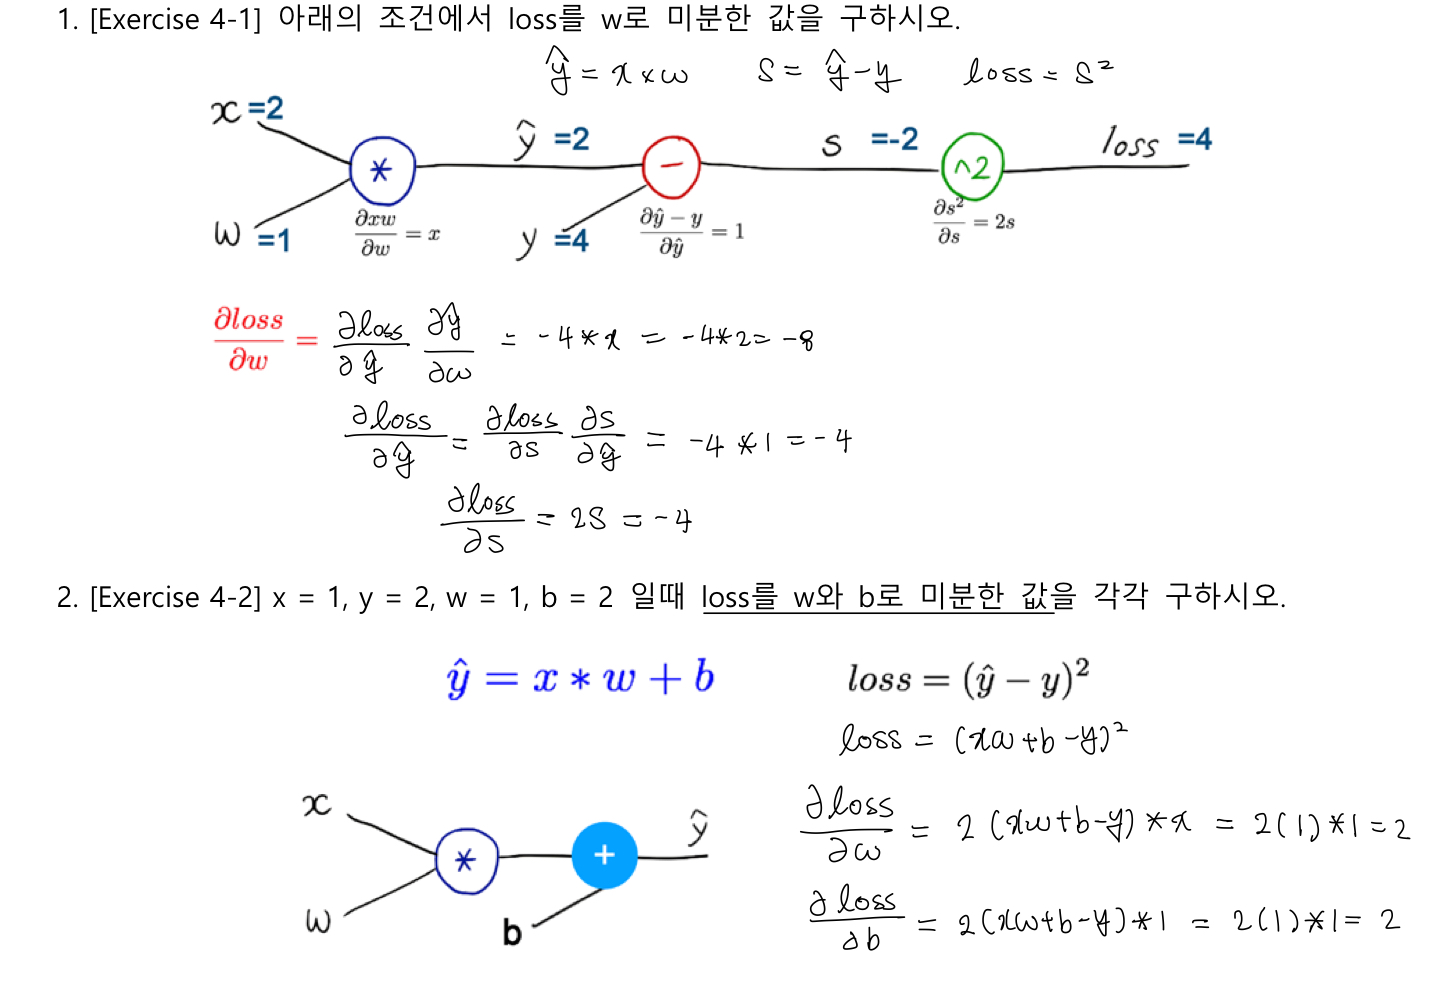

 # 3.[Exercise 4-3]

In [6]:
import numpy as np

x = np.array(2.0)
y = np.array(4.0)
w = np.array(1.0)

# Forward pass
def forward(x):
    return x * w

# Loss function
def loss(x, y):
    y_pred = forward(x)
    s = y_pred - y
    return s ** 2

# Back propagation
def gradient(x, y):
    y_pred = forward(x)
    s = y_pred - y

    d_loss_d_s = 2 * s
    d_s_d_y_pred = 1
    d_y_pred_d_w = x

    return d_loss_d_s * d_s_d_y_pred * d_y_pred_d_w

print("Prediction:", forward(x))
print("Loss:", loss(x, y))
print("Gradient:", gradient(x, y))

Prediction: 2.0
Loss: 4.0
Gradient: -8.0


# 4. [Exercise 4-4]

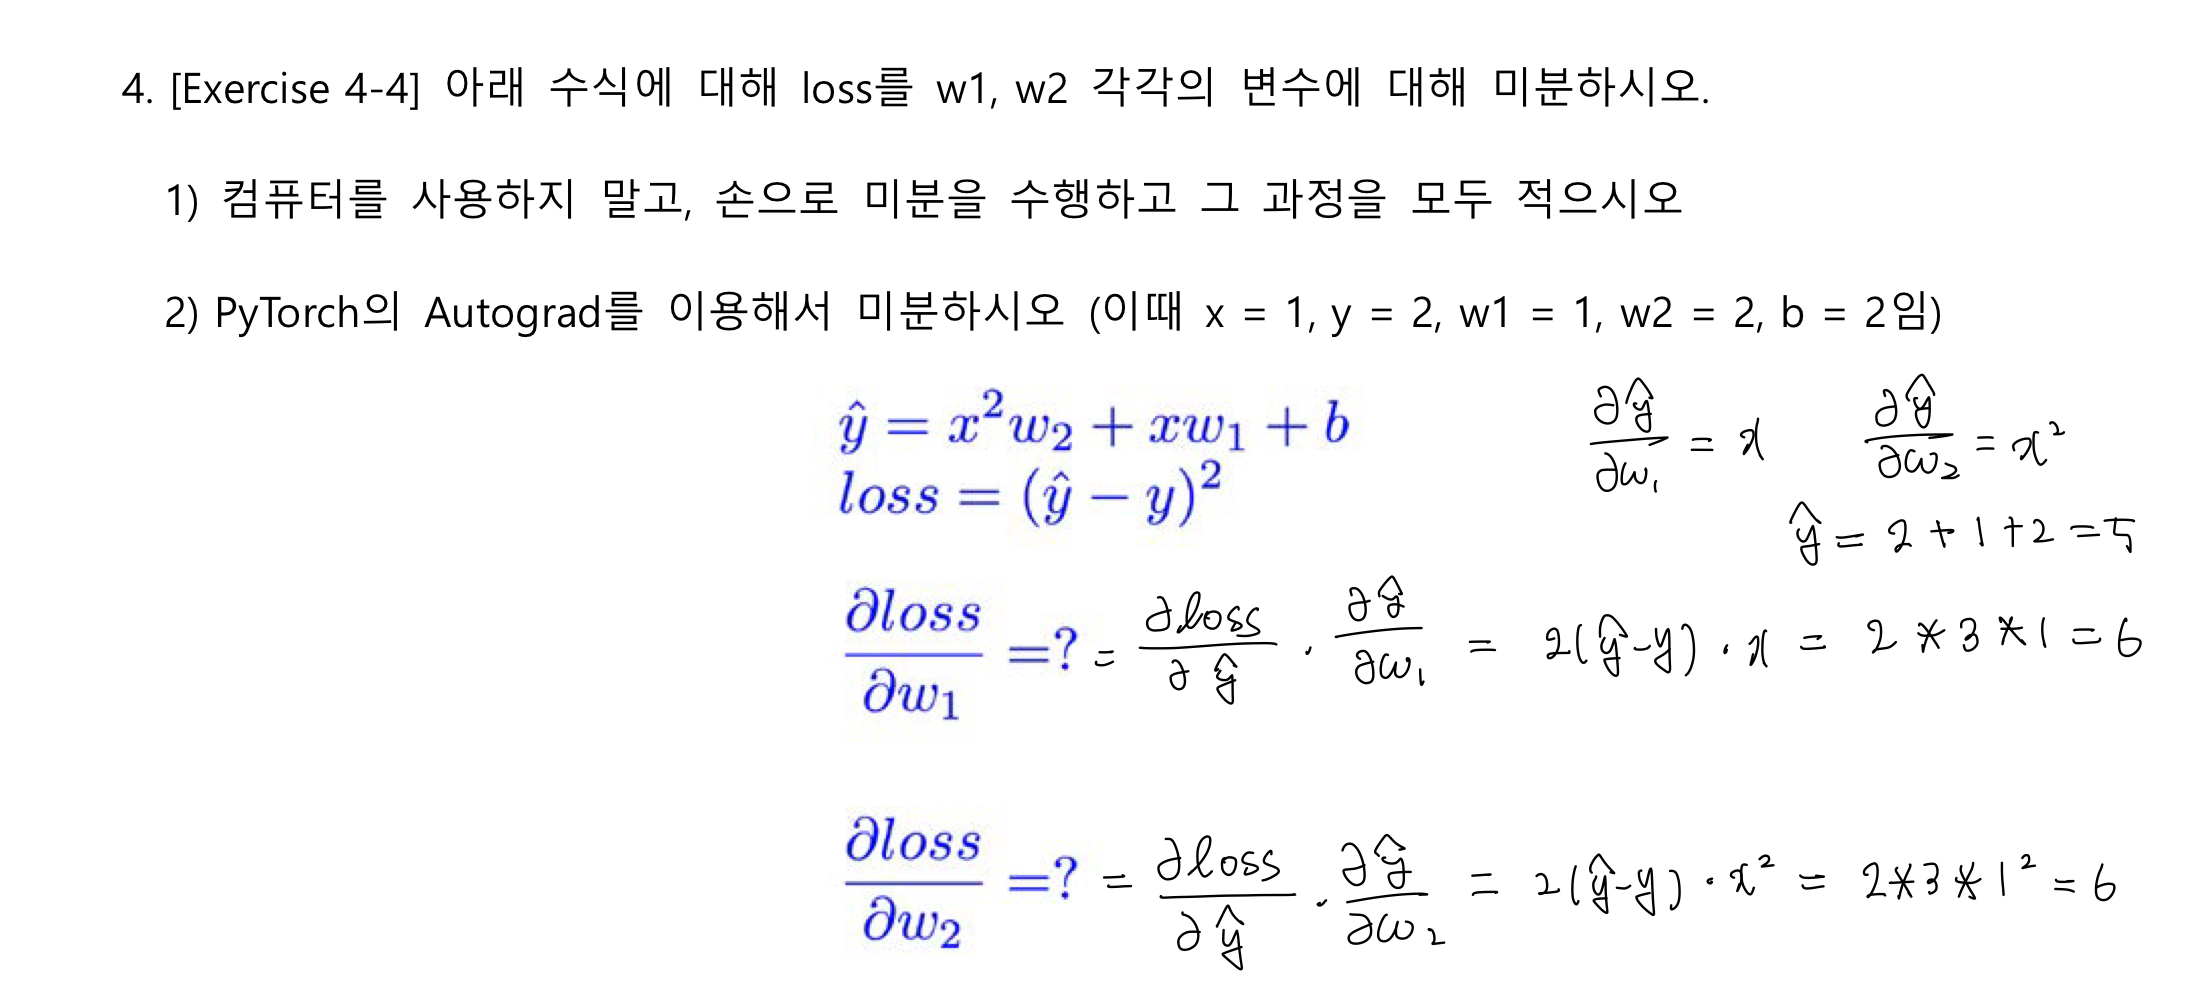

In [7]:
import torch

x = torch.tensor(1.0)
y = torch.tensor(2.0)
b = torch.tensor(2.0)

w1 = torch.tensor(1.0, requires_grad=True)
w2 = torch.tensor(2.0, requires_grad=True)

y_hat = x**2 * w2 + x * w1 + b
loss = (y_hat - y)**2

loss.backward()

print("y_hat:", y_hat.item())
print("loss:", loss.item())
print("dloss/dw1:", w1.grad.item())
print("dloss/dw2:", w2.grad.item())

y_hat: 5.0
loss: 9.0
dloss/dw1: 6.0
dloss/dw2: 6.0


# 5. [Exercise 5-1]

In [8]:
from torch import nn
import torch
from torch import tensor

x_data = tensor([[1.0], [2.0], [3.0]]) #torch.tensor -> torch
y_data = tensor([[2.0], [4.0], [6.0]])


#모델 클래스 정의
class Model(nn.Module):
  def __init__(self):
    """
    in the constructor we instantiate two nn.Linear module
    """

    super(Model,self).__init__()
    self.linear = torch.nn.Linear(1,1)

  def forward(self, x):
    y_pred = self.linear(x)
    return y_pred

#모델
model = Model()


#loss 와 optimizer
criterion = torch.nn.MSELoss(reduction='sum')
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)#학습률

#학습 forward, loss, backward, step

for epoch in range(500):
  y_pred = model(x_data)

  loss = criterion(y_pred, y_data)
  print(f'Epoch: {epoch} | Loss: {loss.item()}')

  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

  #모델 테스트

hour_var = tensor([[4.0]])
y_pred = model(hour_var)
print("Prediction (after training)", 4, model(hour_var).item())

Epoch: 0 | Loss: 42.746986389160156
Epoch: 1 | Loss: 19.31108856201172
Epoch: 2 | Loss: 8.87404727935791
Epoch: 3 | Loss: 4.223789215087891
Epoch: 4 | Loss: 2.14969801902771
Epoch: 5 | Loss: 1.2225008010864258
Epoch: 6 | Loss: 0.805922269821167
Epoch: 7 | Loss: 0.6167128682136536
Epoch: 8 | Loss: 0.5287748575210571
Epoch: 9 | Loss: 0.4859737157821655
Epoch: 10 | Loss: 0.46331852674484253
Epoch: 11 | Loss: 0.4496838450431824
Epoch: 12 | Loss: 0.44011569023132324
Epoch: 13 | Loss: 0.4324076771736145
Epoch: 14 | Loss: 0.42557793855667114
Epoch: 15 | Loss: 0.41918790340423584
Epoch: 16 | Loss: 0.41304120421409607
Epoch: 17 | Loss: 0.4070509076118469
Epoch: 18 | Loss: 0.40117689967155457
Epoch: 19 | Loss: 0.3954002857208252
Epoch: 20 | Loss: 0.3897131681442261
Epoch: 21 | Loss: 0.3841104507446289
Epoch: 22 | Loss: 0.3785892128944397
Epoch: 23 | Loss: 0.37314748764038086
Epoch: 24 | Loss: 0.3677848279476166
Epoch: 25 | Loss: 0.3624992072582245
Epoch: 26 | Loss: 0.3572893738746643
Epoch: 27 |

Epoch: 0 | Loss: 16.83778190612793
Epoch: 1 | Loss: 7.5075507164001465
Epoch: 2 | Loss: 3.3538267612457275
Epoch: 3 | Loss: 1.504537582397461
Epoch: 4 | Loss: 0.6811217069625854
Epoch: 5 | Loss: 0.3143974542617798
Epoch: 6 | Loss: 0.1509813666343689
Epoch: 7 | Loss: 0.07807484269142151
Epoch: 8 | Loss: 0.045462723821401596
Epoch: 9 | Loss: 0.03079099766910076
Epoch: 10 | Loss: 0.024107906967401505
Epoch: 11 | Loss: 0.02098330296576023
Epoch: 12 | Loss: 0.01944505050778389
Epoch: 13 | Loss: 0.018615009263157845
Epoch: 14 | Loss: 0.018102359026670456
Epoch: 15 | Loss: 0.017733078449964523
Epoch: 16 | Loss: 0.017429715022444725
Epoch: 17 | Loss: 0.01715761423110962
Epoch: 18 | Loss: 0.01690136082470417
Epoch: 19 | Loss: 0.01665421389043331
Epoch: 20 | Loss: 0.016412969678640366
Epoch: 21 | Loss: 0.016176164150238037
Epoch: 22 | Loss: 0.015943381935358047
Epoch: 23 | Loss: 0.015714062377810478
Epoch: 24 | Loss: 0.015488098375499249
Epoch: 25 | Loss: 0.01526553649455309
Epoch: 26 | Loss: 0.

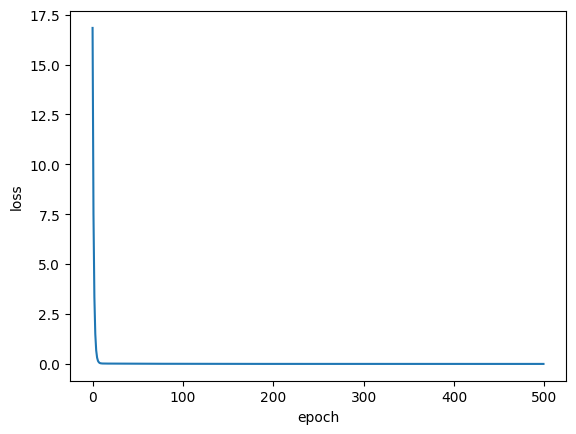

In [9]:
#SGD사용
from torch import nn
import torch
from torch import tensor
import matplotlib.pyplot as plt

x_data = tensor([[1.0], [2.0], [3.0]]) #torch.tensor -> torch
y_data = tensor([[2.0], [4.0], [6.0]])


#모델 클래스 정의
class Model(nn.Module):
  def __init__(self):
    """
    in the constructor we instantiate two nn.Linear module
    """

    super(Model,self).__init__()
    self.linear = torch.nn.Linear(1,1)

  def forward(self, x):
    y_pred = self.linear(x)
    return y_pred

#모델
model = Model()


#loss 와 optimizer
criterion = torch.nn.MSELoss(reduction='sum')
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)#학습률

#학습 forward, loss, backward, step
x = []
y = []
for epoch in range(500):
  y_pred = model(x_data)

  loss = criterion(y_pred, y_data)
  print(f'Epoch: {epoch} | Loss: {loss.item()}')

  optimizer.zero_grad()
  loss.backward()
  optimizer.step()
  x.append(epoch)
  y.append(loss.item())

plt.xlabel("epoch")
plt.ylabel("loss")
plt.plot(x,y)
plt.show()

Epoch: 0 | Loss: 27.00701904296875
Epoch: 1 | Loss: 26.45932388305664
Epoch: 2 | Loss: 26.077573776245117
Epoch: 3 | Loss: 25.769012451171875
Epoch: 4 | Loss: 25.50399398803711
Epoch: 5 | Loss: 25.268648147583008
Epoch: 6 | Loss: 25.05518341064453
Epoch: 7 | Loss: 24.858718872070312
Epoch: 8 | Loss: 24.675949096679688
Epoch: 9 | Loss: 24.50450897216797
Epoch: 10 | Loss: 24.342662811279297
Epoch: 11 | Loss: 24.189056396484375
Epoch: 12 | Loss: 24.042640686035156
Epoch: 13 | Loss: 23.902563095092773
Epoch: 14 | Loss: 23.768129348754883
Epoch: 15 | Loss: 23.638769149780273
Epoch: 16 | Loss: 23.513992309570312
Epoch: 17 | Loss: 23.393386840820312
Epoch: 18 | Loss: 23.276607513427734
Epoch: 19 | Loss: 23.163341522216797
Epoch: 20 | Loss: 23.053314208984375
Epoch: 21 | Loss: 22.94630241394043
Epoch: 22 | Loss: 22.842090606689453
Epoch: 23 | Loss: 22.740497589111328
Epoch: 24 | Loss: 22.6413516998291
Epoch: 25 | Loss: 22.544509887695312
Epoch: 26 | Loss: 22.449832916259766
Epoch: 27 | Loss: 2

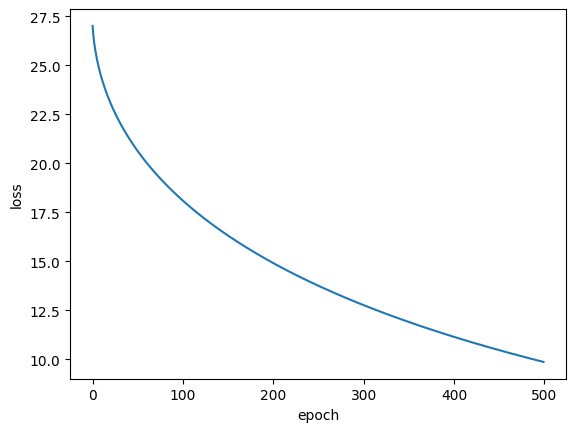

In [10]:
#Adagrad
from torch import nn
import torch
from torch import tensor
import matplotlib.pyplot as plt

x_data = tensor([[1.0], [2.0], [3.0]]) #torch.tensor -> torch
y_data = tensor([[2.0], [4.0], [6.0]])


#모델 클래스 정의
class Model(nn.Module):
  def __init__(self):
    """
    in the constructor we instantiate two nn.Linear module
    """

    super(Model,self).__init__()
    self.linear = torch.nn.Linear(1,1)

  def forward(self, x):
    y_pred = self.linear(x)
    return y_pred

#모델
model = Model()


#loss 와 optimizer
criterion = torch.nn.MSELoss(reduction='sum')
optimizer = torch.optim.Adagrad(model.parameters(), lr=0.01)#학습률

#학습 forward, loss, backward, step
x = []
y = []
for epoch in range(500):
  y_pred = model(x_data)

  loss = criterion(y_pred, y_data)
  print(f'Epoch: {epoch} | Loss: {loss.item()}')

  optimizer.zero_grad()
  loss.backward()
  optimizer.step()
  x.append(epoch)
  y.append(loss.item())

plt.xlabel("epoch")
plt.ylabel("loss")
plt.plot(x,y)
plt.show()

Epoch: 0 | Loss: 143.1373291015625
Epoch: 1 | Loss: 141.85690307617188
Epoch: 2 | Loss: 140.58242797851562
Epoch: 3 | Loss: 139.31399536132812
Epoch: 4 | Loss: 138.05172729492188
Epoch: 5 | Loss: 136.79571533203125
Epoch: 6 | Loss: 135.54603576660156
Epoch: 7 | Loss: 134.30279541015625
Epoch: 8 | Loss: 133.06607055664062
Epoch: 9 | Loss: 131.83596801757812
Epoch: 10 | Loss: 130.612548828125
Epoch: 11 | Loss: 129.3959197998047
Epoch: 12 | Loss: 128.18612670898438
Epoch: 13 | Loss: 126.9832534790039
Epoch: 14 | Loss: 125.78739929199219
Epoch: 15 | Loss: 124.59857177734375
Epoch: 16 | Loss: 123.41690063476562
Epoch: 17 | Loss: 122.24240112304688
Epoch: 18 | Loss: 121.07514953613281
Epoch: 19 | Loss: 119.9151840209961
Epoch: 20 | Loss: 118.76255798339844
Epoch: 21 | Loss: 117.61731719970703
Epoch: 22 | Loss: 116.47950744628906
Epoch: 23 | Loss: 115.34915161132812
Epoch: 24 | Loss: 114.22630310058594
Epoch: 25 | Loss: 113.11097717285156
Epoch: 26 | Loss: 112.00318908691406
Epoch: 27 | Loss:

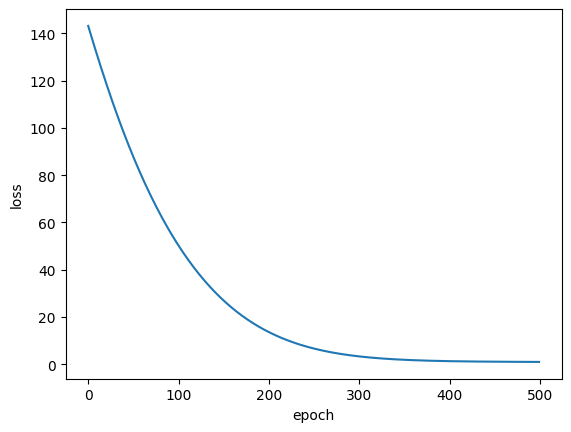

In [11]:
#Adam
from torch import nn
import torch
from torch import tensor
import matplotlib.pyplot as plt

x_data = tensor([[1.0], [2.0], [3.0]]) #torch.tensor -> torch
y_data = tensor([[2.0], [4.0], [6.0]])


#모델 클래스 정의
class Model(nn.Module):
  def __init__(self):
    """
    in the constructor we instantiate two nn.Linear module
    """

    super(Model,self).__init__()
    self.linear = torch.nn.Linear(1,1)

  def forward(self, x):
    y_pred = self.linear(x)
    return y_pred

#모델
model = Model()


#loss 와 optimizer
criterion = torch.nn.MSELoss(reduction='sum')
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)#학습률

#학습 forward, loss, backward, step
x = []
y = []
for epoch in range(500):
  y_pred = model(x_data)

  loss = criterion(y_pred, y_data)
  print(f'Epoch: {epoch} | Loss: {loss.item()}')

  optimizer.zero_grad()
  loss.backward()
  optimizer.step()
  x.append(epoch)
  y.append(loss.item())

plt.xlabel("epoch")
plt.ylabel("loss")
plt.plot(x,y)
plt.show()

Epoch: 0 | Loss: 47.32417297363281
Epoch: 1 | Loss: 46.592613220214844
Epoch: 2 | Loss: 45.869140625
Epoch: 3 | Loss: 45.15380096435547
Epoch: 4 | Loss: 44.446617126464844
Epoch: 5 | Loss: 43.747642517089844
Epoch: 6 | Loss: 43.0568962097168
Epoch: 7 | Loss: 42.37440490722656
Epoch: 8 | Loss: 41.700199127197266
Epoch: 9 | Loss: 41.03428649902344
Epoch: 10 | Loss: 40.37668228149414
Epoch: 11 | Loss: 39.727394104003906
Epoch: 12 | Loss: 39.08642578125
Epoch: 13 | Loss: 38.45377731323242
Epoch: 14 | Loss: 37.82944107055664
Epoch: 15 | Loss: 37.213409423828125
Epoch: 16 | Loss: 36.605655670166016
Epoch: 17 | Loss: 36.00617218017578
Epoch: 18 | Loss: 35.4149284362793
Epoch: 19 | Loss: 34.83189392089844
Epoch: 20 | Loss: 34.25703430175781
Epoch: 21 | Loss: 33.69032287597656
Epoch: 22 | Loss: 33.13170623779297
Epoch: 23 | Loss: 32.581138610839844
Epoch: 24 | Loss: 32.03858184814453
Epoch: 25 | Loss: 31.503971099853516
Epoch: 26 | Loss: 30.97726821899414
Epoch: 27 | Loss: 30.458389282226562
Ep

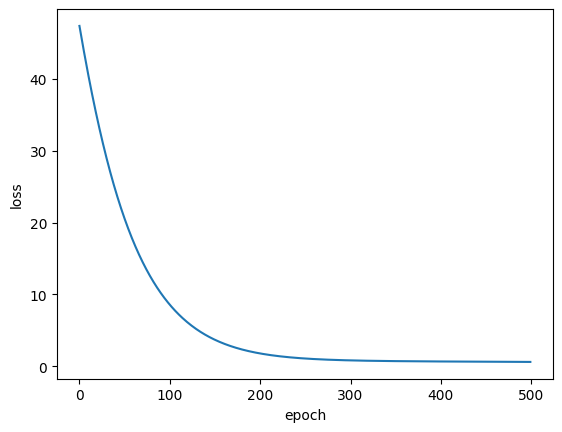

In [12]:
#Adamax사용
from torch import nn
import torch
from torch import tensor
import matplotlib.pyplot as plt

x_data = tensor([[1.0], [2.0], [3.0]]) #torch.tensor -> torch
y_data = tensor([[2.0], [4.0], [6.0]])


#모델 클래스 정의
class Model(nn.Module):
  def __init__(self):
    """
    in the constructor we instantiate two nn.Linear module
    """

    super(Model,self).__init__()
    self.linear = torch.nn.Linear(1,1)

  def forward(self, x):
    y_pred = self.linear(x)
    return y_pred

#모델
model = Model()


#loss 와 optimizer
criterion = torch.nn.MSELoss(reduction='sum')
optimizer = torch.optim.Adamax(model.parameters(), lr=0.01)#학습률

#학습 forward, loss, backward, step
x = []
y = []
for epoch in range(500):
  y_pred = model(x_data)

  loss = criterion(y_pred, y_data)
  print(f'Epoch: {epoch} | Loss: {loss.item()}')

  optimizer.zero_grad()
  loss.backward()
  optimizer.step()
  x.append(epoch)
  y.append(loss.item())

plt.xlabel("epoch")
plt.ylabel("loss")
plt.plot(x,y)
plt.show()

Epoch: 0 | Loss: 95.64653015136719
Epoch: 1 | Loss: 43.26049041748047
Epoch: 2 | Loss: 19.929973602294922
Epoch: 3 | Loss: 9.534246444702148
Epoch: 4 | Loss: 4.896844863891602
Epoch: 5 | Loss: 2.8230223655700684
Epoch: 6 | Loss: 1.8905659914016724
Epoch: 7 | Loss: 1.4663490056991577
Epoch: 8 | Loss: 1.2685182094573975
Epoch: 9 | Loss: 1.1715975999832153
Epoch: 10 | Loss: 1.1197272539138794
Epoch: 11 | Loss: 1.0880382061004639
Epoch: 12 | Loss: 1.0654572248458862
Epoch: 13 | Loss: 1.0470526218414307
Epoch: 14 | Loss: 1.0306274890899658
Epoch: 15 | Loss: 1.0152015686035156
Epoch: 16 | Loss: 1.0003376007080078
Epoch: 17 | Loss: 0.9858389496803284
Epoch: 18 | Loss: 0.9716155529022217
Epoch: 19 | Loss: 0.95762699842453
Epoch: 20 | Loss: 0.9438526630401611
Epoch: 21 | Loss: 0.9302824139595032
Epoch: 22 | Loss: 0.9169101715087891
Epoch: 23 | Loss: 0.9037312269210815
Epoch: 24 | Loss: 0.8907424211502075
Epoch: 25 | Loss: 0.8779399394989014
Epoch: 26 | Loss: 0.8653215169906616
Epoch: 27 | Loss:

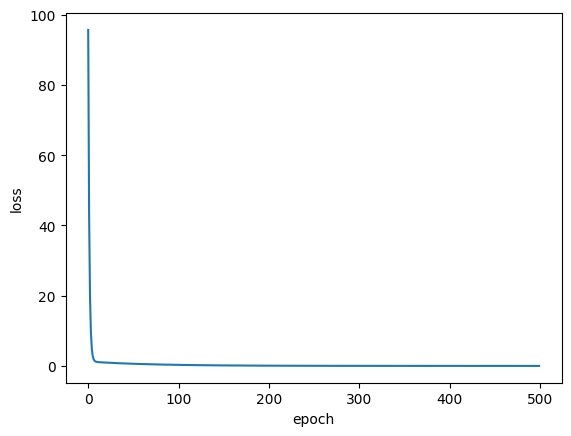

In [13]:
#ASGD
from torch import nn
import torch
from torch import tensor
import matplotlib.pyplot as plt

x_data = tensor([[1.0], [2.0], [3.0]]) #torch.tensor -> torch
y_data = tensor([[2.0], [4.0], [6.0]])


#모델 클래스 정의
class Model(nn.Module):
  def __init__(self):
    """
    in the constructor we instantiate two nn.Linear module
    """

    super(Model,self).__init__()
    self.linear = torch.nn.Linear(1,1)

  def forward(self, x):
    y_pred = self.linear(x)
    return y_pred

#모델
model = Model()


#loss 와 optimizer
criterion = torch.nn.MSELoss(reduction='sum')
optimizer = torch.optim.ASGD(model.parameters(), lr=0.01)#학습률

#학습 forward, loss, backward, step
x = []
y = []
for epoch in range(500):
  y_pred = model(x_data)

  loss = criterion(y_pred, y_data)
  print(f'Epoch: {epoch} | Loss: {loss.item()}')

  optimizer.zero_grad()
  loss.backward()
  optimizer.step()
  x.append(epoch)
  y.append(loss.item())

plt.xlabel("epoch")
plt.ylabel("loss")
plt.plot(x,y)
plt.show()

Epoch: 0 | Loss: 20.644899368286133
Epoch: 1 | Loss: 16.18060302734375
Epoch: 2 | Loss: 13.545557975769043
Epoch: 3 | Loss: 11.663481712341309
Epoch: 4 | Loss: 10.210695266723633
Epoch: 5 | Loss: 9.040456771850586
Epoch: 6 | Loss: 8.072022438049316
Epoch: 7 | Loss: 7.255545616149902
Epoch: 8 | Loss: 6.55778694152832
Epoch: 9 | Loss: 5.955322265625
Epoch: 10 | Loss: 5.430948257446289
Epoch: 11 | Loss: 4.971606731414795
Epoch: 12 | Loss: 4.567131519317627
Epoch: 13 | Loss: 4.209439277648926
Epoch: 14 | Loss: 3.8919835090637207
Epoch: 15 | Loss: 3.609389305114746
Epoch: 16 | Loss: 3.3571829795837402
Epoch: 17 | Loss: 3.1316041946411133
Epoch: 18 | Loss: 2.9294650554656982
Epoch: 19 | Loss: 2.7480292320251465
Epoch: 20 | Loss: 2.5849456787109375
Epoch: 21 | Loss: 2.438176393508911
Epoch: 22 | Loss: 2.3059399127960205
Epoch: 23 | Loss: 2.1866796016693115
Epoch: 24 | Loss: 2.0790257453918457
Epoch: 25 | Loss: 1.9817688465118408
Epoch: 26 | Loss: 1.8938355445861816
Epoch: 27 | Loss: 1.8142753

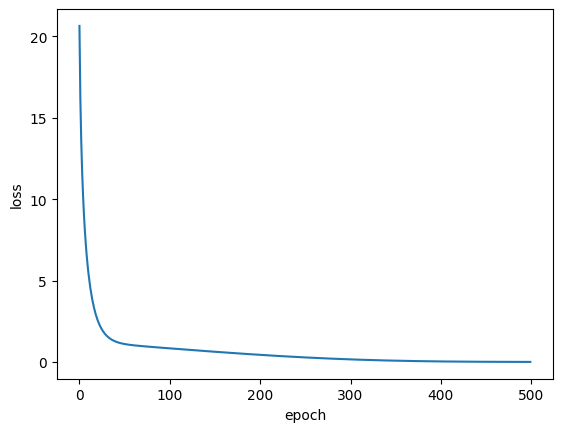

In [14]:
#RMSprop
from torch import nn
import torch
from torch import tensor
import matplotlib.pyplot as plt

x_data = tensor([[1.0], [2.0], [3.0]]) #torch.tensor -> torch
y_data = tensor([[2.0], [4.0], [6.0]])


#모델 클래스 정의
class Model(nn.Module):
  def __init__(self):
    """
    in the constructor we instantiate two nn.Linear module
    """

    super(Model,self).__init__()
    self.linear = torch.nn.Linear(1,1)

  def forward(self, x):
    y_pred = self.linear(x)
    return y_pred

#모델
model = Model()


#loss 와 optimizer
criterion = torch.nn.MSELoss(reduction='sum')
optimizer = torch.optim.RMSprop(model.parameters(), lr=0.01)#학습률

#학습 forward, loss, backward, step
x = []
y = []
for epoch in range(500):
  y_pred = model(x_data)

  loss = criterion(y_pred, y_data)
  print(f'Epoch: {epoch} | Loss: {loss.item()}')

  optimizer.zero_grad()
  loss.backward()
  optimizer.step()
  x.append(epoch)
  y.append(loss.item())

plt.xlabel("epoch")
plt.ylabel("loss")
plt.plot(x,y)
plt.show()

Epoch: 0 | Loss: 9.275160789489746
Epoch: 1 | Loss: 8.967247009277344
Epoch: 2 | Loss: 8.605406761169434
Epoch: 3 | Loss: 8.182222366333008
Epoch: 4 | Loss: 7.690276622772217
Epoch: 5 | Loss: 7.122802734375
Epoch: 6 | Loss: 6.474754333496094
Epoch: 7 | Loss: 5.744498252868652
Epoch: 8 | Loss: 4.9364542961120605
Epoch: 9 | Loss: 4.065098762512207
Epoch: 10 | Loss: 3.161017894744873
Epoch: 11 | Loss: 2.2799489498138428
Epoch: 12 | Loss: 1.5161794424057007
Epoch: 13 | Loss: 1.022315502166748
Epoch: 14 | Loss: 1.0383063554763794
Epoch: 15 | Loss: 1.0383063554763794
Epoch: 16 | Loss: 0.9473162889480591
Epoch: 17 | Loss: 0.8998662233352661
Epoch: 18 | Loss: 0.8193264007568359
Epoch: 19 | Loss: 0.7308444976806641
Epoch: 20 | Loss: 0.6364243030548096
Epoch: 21 | Loss: 0.5400530695915222
Epoch: 22 | Loss: 0.444762647151947
Epoch: 23 | Loss: 0.37403014302253723
Epoch: 24 | Loss: 0.3250102698802948
Epoch: 25 | Loss: 0.2661510407924652
Epoch: 26 | Loss: 0.20816072821617126
Epoch: 27 | Loss: 0.1772

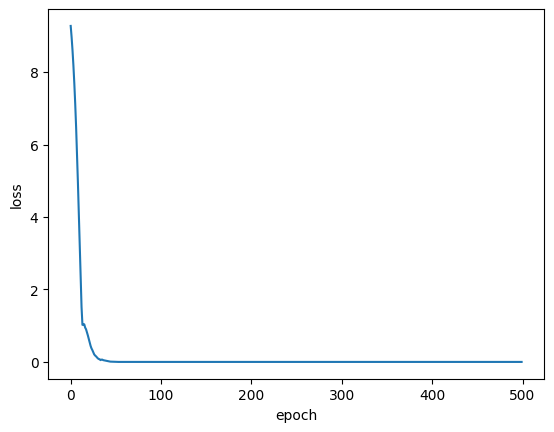

In [15]:
#Rprop
from torch import nn
import torch
from torch import tensor
import matplotlib.pyplot as plt

x_data = tensor([[1.0], [2.0], [3.0]]) #torch.tensor -> torch
y_data = tensor([[2.0], [4.0], [6.0]])


#모델 클래스 정의
class Model(nn.Module):
  def __init__(self):
    """
    in the constructor we instantiate two nn.Linear module
    """

    super(Model,self).__init__()
    self.linear = torch.nn.Linear(1,1)

  def forward(self, x):
    y_pred = self.linear(x)
    return y_pred

#모델
model = Model()


#loss 와 optimizer
criterion = torch.nn.MSELoss(reduction='sum')
optimizer = torch.optim.Rprop(model.parameters(), lr=0.01)#학습률

#학습 forward, loss, backward, step
x = []
y = []
for epoch in range(500):
  y_pred = model(x_data)

  loss = criterion(y_pred, y_data)
  print(f'Epoch: {epoch} | Loss: {loss.item()}')

  optimizer.zero_grad()
  loss.backward()
  optimizer.step()
  x.append(epoch)
  y.append(loss.item())

plt.xlabel("epoch")
plt.ylabel("loss")
plt.plot(x,y)
plt.show()

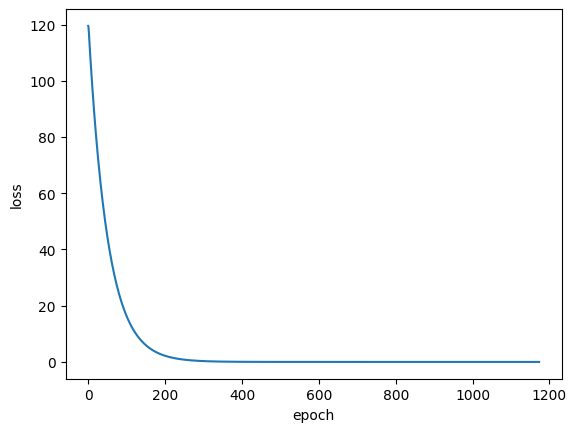

In [16]:
#LBFGS
from torch import nn
import torch
from torch import tensor
import matplotlib.pyplot as plt

x_data = tensor([[1.0], [2.0], [3.0]])
y_data = tensor([[2.0], [4.0], [6.0]])

class Model(nn.Module):
    def __init__(self):
        super(Model, self).__init__()
        self.linear = torch.nn.Linear(1, 1)

    def forward(self, x):
        y_pred = self.linear(x)
        return y_pred

model = Model()
criterion = torch.nn.MSELoss(reduction='sum')
optimizer = torch.optim.LBFGS(model.parameters(), lr=0.01)

x = []
y = []
def closure():
    optimizer.zero_grad()
    y_pred = model(x_data)
    loss = criterion(y_pred, y_data)
    loss.backward()
    x.append(len(x))
    y.append(loss.item())
    return loss

for epoch in range(100):
    optimizer.step(closure)

plt.xlabel("epoch")
plt.ylabel("loss")
plt.plot(x, y)
plt.show()

# 6. [Exercise 6-1]

In [17]:
from torch import tensor
from torch import nn
from torch import sigmoid
import torch.nn.functional as F
import torch.optim as optim

x_data = tensor([[1.0], [2.0], [3.0], [4.0]])
y_data = tensor([[0.], [0.], [1.], [1.]])

In [19]:
class Model(nn.Module):
  def __init__(self):
    super(Model, self).__init__()
    self.linear = nn.Linear(1, 1)

  def forward(self, x):
    y_pred = sigmoid(self.linear(x))
    return y_pred

model = Model()

criterion = nn.BCELoss(reduction='mean')
optimizer = optim.SGD(model.parameters(), lr=0.01)

#Training loop
for epoch in range(1000):
  y_pred = model(x_data)

  loss = criterion(y_pred, y_data)
  print(f'Epoch {epoch +1}/1000 | loss : {loss.item():.4f}')

  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

#After training
print(f'\nLet\'s predict the hours need to score above 50%\n{"="*50}')
hour_var = model(tensor([[1.0]]))
print(f'Prediction after 1 hour of training: {hour_var.item(): 4f} | Above 50% {hour_var.item() > 0.5}')
hour_var = model(tensor([[7.0]]))
print(f'Prediction after 7 hours of training: {hour_var.item(): 4f} | Above 50%: { hour_var.item()>0.5}')


Epoch 1/1000 | loss : 1.1759
Epoch 2/1000 | loss : 1.1617
Epoch 3/1000 | loss : 1.1479
Epoch 4/1000 | loss : 1.1344
Epoch 5/1000 | loss : 1.1213
Epoch 6/1000 | loss : 1.1085
Epoch 7/1000 | loss : 1.0961
Epoch 8/1000 | loss : 1.0840
Epoch 9/1000 | loss : 1.0722
Epoch 10/1000 | loss : 1.0608
Epoch 11/1000 | loss : 1.0497
Epoch 12/1000 | loss : 1.0389
Epoch 13/1000 | loss : 1.0284
Epoch 14/1000 | loss : 1.0183
Epoch 15/1000 | loss : 1.0084
Epoch 16/1000 | loss : 0.9989
Epoch 17/1000 | loss : 0.9896
Epoch 18/1000 | loss : 0.9807
Epoch 19/1000 | loss : 0.9720
Epoch 20/1000 | loss : 0.9637
Epoch 21/1000 | loss : 0.9556
Epoch 22/1000 | loss : 0.9477
Epoch 23/1000 | loss : 0.9402
Epoch 24/1000 | loss : 0.9329
Epoch 25/1000 | loss : 0.9258
Epoch 26/1000 | loss : 0.9190
Epoch 27/1000 | loss : 0.9124
Epoch 28/1000 | loss : 0.9060
Epoch 29/1000 | loss : 0.8999
Epoch 30/1000 | loss : 0.8940
Epoch 31/1000 | loss : 0.8883
Epoch 32/1000 | loss : 0.8828
Epoch 33/1000 | loss : 0.8775
Epoch 34/1000 | los

In [20]:
#Sigmoid

x_data = tensor([[1.0], [2.0], [3.0], [4.0]])
y_data = tensor([[0.], [0.], [1.], [1.]])

class Model(nn.Module):
  def __init__(self):
    super(Model, self).__init__()
    self.linear = nn.Linear(1, 1)

  def forward(self, x):
    y_pred = sigmoid(self.linear(x))
    return y_pred

model = Model()

criterion = nn.BCELoss(reduction='mean')
optimizer = optim.SGD(model.parameters(), lr=0.01)

#Training loop
for epoch in range(1000):
  y_pred = model(x_data)

  loss = criterion(y_pred, y_data)
  print(f'Epoch {epoch +1}/1000 | loss : {loss.item():.4f}')

  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

  #After training
print(f'\nLet\'s predict the hours need to score above 50%\n{"="*50}')
hour_var = model(tensor([[1.0]]))
print(f'Prediction after 1 hour of training: {hour_var.item(): 4f} | Above 50% {hour_var.item() > 0.5}')
hour_var = model(tensor([[7.0]]))
print(f'Prediction after 7 hours of training: {hour_var.item(): 4f} | Above 50%: { hour_var.item()>0.5}')

Epoch 1/1000 | loss : 0.6950
Epoch 2/1000 | loss : 0.6917
Epoch 3/1000 | loss : 0.6885
Epoch 4/1000 | loss : 0.6853
Epoch 5/1000 | loss : 0.6821
Epoch 6/1000 | loss : 0.6790
Epoch 7/1000 | loss : 0.6759
Epoch 8/1000 | loss : 0.6728
Epoch 9/1000 | loss : 0.6698
Epoch 10/1000 | loss : 0.6668
Epoch 11/1000 | loss : 0.6639
Epoch 12/1000 | loss : 0.6610
Epoch 13/1000 | loss : 0.6581
Epoch 14/1000 | loss : 0.6553
Epoch 15/1000 | loss : 0.6525
Epoch 16/1000 | loss : 0.6497
Epoch 17/1000 | loss : 0.6470
Epoch 18/1000 | loss : 0.6443
Epoch 19/1000 | loss : 0.6417
Epoch 20/1000 | loss : 0.6391
Epoch 21/1000 | loss : 0.6365
Epoch 22/1000 | loss : 0.6340
Epoch 23/1000 | loss : 0.6315
Epoch 24/1000 | loss : 0.6290
Epoch 25/1000 | loss : 0.6266
Epoch 26/1000 | loss : 0.6242
Epoch 27/1000 | loss : 0.6219
Epoch 28/1000 | loss : 0.6195
Epoch 29/1000 | loss : 0.6173
Epoch 30/1000 | loss : 0.6150
Epoch 31/1000 | loss : 0.6128
Epoch 32/1000 | loss : 0.6106
Epoch 33/1000 | loss : 0.6085
Epoch 34/1000 | los

In [22]:
#relu

from torch import tensor
from torch import nn
from torch import sigmoid
import torch.nn.functional as F
import torch.optim as optim
from torch.autograd import Variable

x_data = Variable(torch.Tensor([[1.0], [2.0], [3.0], [4.0]]))
y_data = Variable(torch.Tensor([[0.], [0.], [1.], [1.]]))

x_max = torch.max(x_data)
x_data = x_data / x_max

class Model(torch.nn.Module):
    def __init__(self):
        super(Model, self).__init__()
        self.linear = torch.nn.Linear(1, 1)  # One in and one out

    def forward(self, x):
        x = self.linear(x)
        y_pred = F.relu(x)
        y_pred = (y_pred + 1) / 2.0
        return y_pred

# our model
model = Model()
criterion = torch.nn.BCELoss(size_average=True)
optimizer = torch.optim.SGD(model.parameters(), lr=0.001)

# Training loop
for epoch in range(1000):
  # Forward pass: Compute predicted y by passing x to the model
  y_pred = model(x_data)

  # Compute and print loss
  loss = criterion(y_pred, y_data)
  print(epoch, loss.item())

# Zero gradients, perform a backward pass, and update the weights.
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

# After training
hour_var = Variable(torch.Tensor([[1.0]]))
hour_var = hour_var / x_max
print("predict 1 hour ", 1.0, model(hour_var).data[0][0] > 0.5)
hour_var = Variable(torch.Tensor([[7.0]]))
hour_var = hour_var / x_max
print("predict 7 hours", 7.0, model(hour_var).data[0][0] > 0.5)

/usr/local/lib/python3.13/dist-packages/torch/nn/modules/loss.py:44: UserWarning: size_average and reduce args will be deprecated, please use reduction='mean' instead.
  self.reduction: str = _Reduction.legacy_get_string(size_average, reduce)


0 0.8699604272842407
1 0.869688868522644
2 0.8694181442260742
3 0.8691482543945312
4 0.8688791990280151
5 0.8686107993125916
6 0.8683432936668396
7 0.8680765628814697
8 0.8678106069564819
9 0.8675455451011658
10 0.8672812581062317
11 0.8670176267623901
12 0.8667548298835754
13 0.8664928674697876
14 0.8662316203117371
15 0.8659710884094238
16 0.865711510181427
17 0.8654525876045227
18 0.8651943802833557
19 0.864936888217926
20 0.8646802306175232
21 0.8644242882728577
22 0.8641692399978638
23 0.8639147281646729
24 0.8636611104011536
25 0.8634082078933716
26 0.8631559014320374
27 0.8629044890403748
28 0.8626537322998047
29 0.8624037504196167
30 0.8621543645858765
31 0.8619057536125183
32 0.861657977104187
33 0.8614107966423035
34 0.8611643314361572
35 0.8609186410903931
36 0.8606735467910767
37 0.8604292869567871
38 0.8601856231689453
39 0.8599427342414856
40 0.8597004413604736
41 0.8594589233398438
42 0.8592180609703064
43 0.8589779138565063
44 0.8587384819984436
45 0.8584996461868286
46

In [23]:
#relu6

from torch import tensor
from torch import nn
import torch.nn.functional as F
import torch.optim as optim
from torch.autograd import Variable

x_data = Variable(torch.Tensor([[1.0], [2.0], [3.0], [4.0]]))
y_data = Variable(torch.Tensor([[0.], [0.], [1.], [1.]]))

x_max = torch.max(x_data)
x_data = x_data / x_max

class Model(torch.nn.Module):
    def __init__(self):
        super(Model, self).__init__()
        self.linear = torch.nn.Linear(1, 1)  # One in and one out

    def forward(self, x):
        x = self.linear(x)
        y_pred = F.relu6(x)
        return y_pred

# Our model
model = Model()
criterion = torch.nn.BCELoss(size_average=True)
optimizer = torch.optim.SGD(model.parameters(), lr=0.001)

# Training loop
for epoch in range(1000):
    # Forward pass: Compute predicted y by passing x to the model
    y_pred = model(x_data)

    # Compute and print loss
    loss = criterion(y_pred, y_data)
    print(epoch, loss.item())

    # Zero gradients, perform a backward pass, and update the weights.
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

# After training
hour_var = Variable(torch.Tensor([[1.0]]))
hour_var = hour_var / x_max
print("predict 1 hour ", 1.0, model(hour_var).data[0][0] > 0.5)
hour_var = Variable(torch.Tensor([[7.0]]))
hour_var = hour_var / x_max
print("predict 7 hours", 7.0, model(hour_var).data[0][0] > 0.5)

0 50.0
1 50.0
2 50.0
3 50.0
4 50.0
5 50.0
6 50.0
7 50.0
8 50.0
9 50.0
10 50.0
11 50.0
12 50.0
13 50.0
14 50.0
15 50.0
16 50.0
17 50.0
18 50.0
19 50.0
20 50.0
21 50.0
22 50.0
23 50.0
24 50.0
25 50.0
26 50.0
27 50.0
28 50.0
29 50.0
30 50.0
31 50.0
32 50.0
33 50.0
34 50.0
35 50.0
36 50.0
37 50.0
38 50.0
39 50.0
40 50.0
41 50.0
42 50.0
43 50.0
44 50.0
45 50.0
46 50.0
47 50.0
48 50.0
49 50.0
50 50.0
51 50.0
52 50.0
53 50.0
54 50.0
55 50.0
56 50.0
57 50.0
58 50.0
59 50.0
60 50.0
61 50.0
62 50.0
63 50.0
64 50.0
65 50.0
66 50.0
67 50.0
68 50.0
69 50.0
70 50.0
71 50.0
72 50.0
73 50.0
74 50.0
75 50.0
76 50.0
77 50.0
78 50.0
79 50.0
80 50.0
81 50.0
82 50.0
83 50.0
84 50.0
85 50.0
86 50.0
87 50.0
88 50.0
89 50.0
90 50.0
91 50.0
92 50.0
93 50.0
94 50.0
95 50.0
96 50.0
97 50.0
98 50.0
99 50.0
100 50.0
101 50.0
102 50.0
103 50.0
104 50.0
105 50.0
106 50.0
107 50.0
108 50.0
109 50.0
110 50.0
111 50.0
112 50.0
113 50.0
114 50.0
115 50.0
116 50.0
117 50.0
118 50.0
119 50.0
120 50.0
121 50.0
122 50.0
123

In [24]:
#ELU

from torch import tensor
from torch import nn
import torch.nn.functional as F
import torch.optim as optim
from torch.autograd import Variable

x_data = Variable(torch.Tensor([[1.0], [2.0], [3.0], [4.0]]))
y_data = Variable(torch.Tensor([[0.], [0.], [1.], [1.]]))

x_max = torch.max(x_data)
x_data = x_data / x_max

class Model(torch.nn.Module):
    def __init__(self):
        super(Model, self).__init__()
        self.linear = torch.nn.Linear(1, 1)  # One in and one out
        self.elu = nn.ELU()

    def forward(self, x):
        x = self.linear(x)
        y_pred = self.elu(x)
        y_pred = (y_pred + 1) / 2.0
        return y_pred

# Our model
model = Model()
criterion = torch.nn.BCELoss(size_average=True)
optimizer = torch.optim.SGD(model.parameters(), lr=0.001)

# Training loop
for epoch in range(1000):
    # Forward pass: Compute predicted y by passing x to the model
    y_pred = model(x_data)

    # Compute and print loss
    loss = criterion(y_pred, y_data)
    print(epoch, loss.item())

    # Zero gradients, perform a backward pass, and update the weights.
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

# After training
hour_var = Variable(torch.Tensor([[1.0]]))
hour_var = hour_var / x_max
print("predict 1 hour ", 1.0, model(hour_var).data[0][0] > 0.5)
hour_var = Variable(torch.Tensor([[7.0]]))
hour_var = hour_var / x_max
print("predict 7 hours", 7.0, model(hour_var).data[0][0] > 0.5)

0 1.1734626293182373
1 1.1731593608856201
2 1.1728562116622925
3 1.172553300857544
4 1.172250509262085
5 1.1719474792480469
6 1.171644687652588
7 1.1713420152664185
8 1.1710395812988281
9 1.1707370281219482
10 1.1704344749450684
11 1.1701321601867676
12 1.1698298454284668
13 1.1695276498794556
14 1.1692254543304443
15 1.1689233779907227
16 1.16862154006958
17 1.1683197021484375
18 1.168017864227295
19 1.1677160263061523
20 1.1674143075942993
21 1.1671128273010254
22 1.166811466217041
23 1.166509985923767
24 1.1662087440490723
25 1.1659075021743774
26 1.1656062602996826
27 1.1653051376342773
28 1.1650043725967407
29 1.164703369140625
30 1.1644024848937988
31 1.1641017198562622
32 1.1638010740280151
33 1.1635005474090576
34 1.1632000207901
35 1.1628994941711426
36 1.1625992059707642
37 1.1622990369796753
38 1.1619987487792969
39 1.161698579788208
40 1.1613986492156982
41 1.1610987186431885
42 1.1607989072799683
43 1.160499095916748
44 1.1601994037628174
45 1.1598998308181763
46 1.1596002

In [26]:
#SELU
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

x_data = torch.tensor([[1.0], [2.0], [3.0], [4.0]])
y_data = torch.tensor([[0.0], [0.0], [1.0], [1.0]])

x_max = torch.max(x_data)
x_data = x_data / x_max

class Model(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear1 = nn.Linear(1, 4)  # 은닉층
        self.linear2 = nn.Linear(4, 1)  # 출력층

    def forward(self, x):
        x = F.selu(self.linear1(x))
        y_pred = torch.sigmoid(self.linear2(x))
        return y_pred

model = Model()
criterion = nn.BCELoss()
optimizer = optim.SGD(model.parameters(), lr=0.1)

for epoch in range(1000):
    y_pred = model(x_data)
    loss = criterion(y_pred, y_data)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch % 100 == 0:
        print(epoch, loss.item())

with torch.no_grad():
    for hour in [1.0, 7.0]:
        hour_data = torch.tensor([[hour]]) / x_max
        probability = model(hour_data).item()

        print(
            f"predict {hour:g} hours:",
            probability,
            probability > 0.5
        )

0 0.738781213760376
100 0.6582144498825073
200 0.43821173906326294
300 0.19510026276111603
400 0.11235201358795166
500 0.07566039264202118
600 0.055446475744247437
700 0.042871829122304916
800 0.0344250351190567
900 0.02843635343015194
predict 1 hours: 0.00037126048118807375 False
predict 7 hours: 0.999963641166687 True


In [27]:
#PReLU

from torch import tensor
from torch import nn
import torch.nn.functional as F
import torch.optim as optim
from torch.autograd import Variable

x_data = Variable(torch.Tensor([[1.0], [2.0], [3.0], [4.0]]))
y_data = Variable(torch.Tensor([[0.], [0.], [1.], [1.]]))

x_max = torch.max(x_data)
x_data = x_data / x_max

class Model(torch.nn.Module):
    def __init__(self):
        super(Model, self).__init__()
        self.linear = torch.nn.Linear(1, 1)  # One in and one out
        self.prelu = nn.PReLU()  # PreLU activation

    def forward(self, x):
        x = self.linear(x)
        y_pred = self.prelu(x)
        y_pred = (y_pred + 1) / 2.0
        return y_pred

# Our model
model = Model()
criterion = torch.nn.BCELoss(size_average=True)
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

# Training loop
for epoch in range(1000):
    # Forward pass: Compute predicted y by passing x to the model
    y_pred = model(x_data)

    # Compute and print loss
    loss = criterion(y_pred, y_data)
    print(epoch, loss.item())

    # Zero gradients, perform a backward pass, and update the weights.
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

# After training
hour_var = Variable(torch.Tensor([[1.0]]))
hour_var = hour_var / x_max
print("predict 1 hour ", 1.0, model(hour_var).data[0][0] > 0.5)
hour_var = Variable(torch.Tensor([[7.0]]))
hour_var = hour_var / x_max
print("predict 7 hours", 7.0, model(hour_var).data[0][0] > 0.5)

0 0.7974862456321716
1 0.7918424606323242
2 0.7866030335426331
3 0.7817260026931763
4 0.7771753668785095
5 0.7729198336601257
6 0.7689322829246521
7 0.7651888728141785
8 0.7616687417030334
9 0.7583534717559814
10 0.7552264928817749
11 0.7522732615470886
12 0.749480664730072
13 0.7468367218971252
14 0.7443310022354126
15 0.7419538497924805
16 0.7396965622901917
17 0.7375510931015015
18 0.7355102300643921
19 0.733567476272583
20 0.7317166328430176
21 0.7299521565437317
22 0.7282689809799194
23 0.726662278175354
24 0.7251276969909668
25 0.7236613035202026
26 0.7222591638565063
27 0.7209179401397705
28 0.7196342945098877
29 0.7184052467346191
30 0.7172279357910156
31 0.7160998582839966
32 0.7150183916091919
33 0.7139812707901001
34 0.712986409664154
35 0.7120317220687866
36 0.7111151814460754
37 0.7102351188659668
38 0.709389865398407
39 0.7085777521133423
40 0.7077972888946533
41 0.7070470452308655
42 0.7063257694244385
43 0.7056320905685425
44 0.704964816570282
45 0.7043228149414062
46 0

In [30]:
#PReLU
import torch
from torch import nn
import torch.optim as optim

x_data = torch.tensor([[1.0], [2.0], [3.0], [4.0]])
y_data = torch.tensor([[0.0], [0.0], [1.0], [1.0]])

x_max = torch.max(x_data)
x_data = x_data / x_max

class Model(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(1, 1)
        self.prelu = nn.PReLU(init=0.1)

    def forward(self, x):
        y_pred = self.linear(x)
        y_pred = self.prelu(y_pred)
        y_pred = torch.sigmoid(y_pred)  # BCELoss를 위해 0~1로 변환
        return y_pred

model = Model()
criterion = nn.BCELoss()
optimizer = optim.SGD(model.parameters(), lr=0.001)

for epoch in range(1000):
    y_pred = model(x_data)
    loss = criterion(y_pred, y_data)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch % 100 == 0:
        print(epoch, loss.item())

with torch.no_grad():
    for hour in [1.0, 7.0]:
        hour_data = torch.tensor([[hour]]) / x_max
        probability = model(hour_data).item()
        print(f"predict {hour:g} hours:", probability > 0.5)

0 0.6939293146133423
100 0.6938854455947876
200 0.6938434839248657
300 0.693803608417511
400 0.6937656998634338
500 0.6937295198440552
600 0.693695068359375
700 0.693662166595459
800 0.6936306953430176
900 0.6936008334159851
predict 1 hours: False
predict 7 hours: False


In [29]:
#thereshold

from torch import tensor
from torch import nn
import torch.nn.functional as F
import torch.optim as optim
from torch.autograd import Variable

x_data = Variable(torch.Tensor([[1.0], [2.0], [3.0], [4.0]]))
y_data = Variable(torch.Tensor([[0.], [0.], [1.], [1.]]))

x_max = torch.max(x_data)
x_data = x_data / x_max

class Model(torch.nn.Module):
    def __init__(self):
        super(Model, self).__init__()
        self.linear = torch.nn.Linear(1, 1)  # One in and one out
        self.threshold = nn.Threshold(0.5, 0)

    def forward(self, x):
        x = self.linear(x)
        y_pred = self.threshold(x)
        return y_pred

# Our model
model = Model()
criterion = torch.nn.BCELoss(size_average=True)
optimizer = torch.optim.SGD(model.parameters(), lr=0.0001)

# Training loop
for epoch in range(1000):
    # Forward pass: Compute predicted y by passing x to the model
    y_pred = model(x_data)

    # Compute and print loss
    loss = criterion(y_pred, y_data)
    print(epoch, loss.item())

    # Zero gradients, perform a backward pass, and update the weights.
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

# After training
hour_var = Variable(torch.Tensor([[1.0]]))
hour_var = hour_var / x_max
print("predict 1 hour ", 1.0, model(hour_var).data[0][0] > 0.5)
hour_var = Variable(torch.Tensor([[7.0]]))
hour_var = hour_var / x_max
print("predict 7 hours", 7.0, model(hour_var).data[0][0] > 0.5)

0 50.0
1 50.0
2 50.0
3 50.0
4 50.0
5 50.0
6 50.0
7 50.0
8 50.0
9 50.0
10 50.0
11 50.0
12 50.0
13 50.0
14 50.0
15 50.0
16 50.0
17 50.0
18 50.0
19 50.0
20 50.0
21 50.0
22 50.0
23 50.0
24 50.0
25 50.0
26 50.0
27 50.0
28 50.0
29 50.0
30 50.0
31 50.0
32 50.0
33 50.0
34 50.0
35 50.0
36 50.0
37 50.0
38 50.0
39 50.0
40 50.0
41 50.0
42 50.0
43 50.0
44 50.0
45 50.0
46 50.0
47 50.0
48 50.0
49 50.0
50 50.0
51 50.0
52 50.0
53 50.0
54 50.0
55 50.0
56 50.0
57 50.0
58 50.0
59 50.0
60 50.0
61 50.0
62 50.0
63 50.0
64 50.0
65 50.0
66 50.0
67 50.0
68 50.0
69 50.0
70 50.0
71 50.0
72 50.0
73 50.0
74 50.0
75 50.0
76 50.0
77 50.0
78 50.0
79 50.0
80 50.0
81 50.0
82 50.0
83 50.0
84 50.0
85 50.0
86 50.0
87 50.0
88 50.0
89 50.0
90 50.0
91 50.0
92 50.0
93 50.0
94 50.0
95 50.0
96 50.0
97 50.0
98 50.0
99 50.0
100 50.0
101 50.0
102 50.0
103 50.0
104 50.0
105 50.0
106 50.0
107 50.0
108 50.0
109 50.0
110 50.0
111 50.0
112 50.0
113 50.0
114 50.0
115 50.0
116 50.0
117 50.0
118 50.0
119 50.0
120 50.0
121 50.0
122 50.0
123

In [31]:
#hardtanh

from torch import tensor
from torch import nn
import torch.nn.functional as F
import torch.optim as optim
from torch.autograd import Variable

x_data = Variable(torch.Tensor([[1.0], [2.0], [3.0], [4.0]]))
y_data = Variable(torch.Tensor([[0.], [0.], [1.], [1.]]))

x_max = torch.max(x_data)
x_data = x_data / x_max

class Model(torch.nn.Module):
    def __init__(self):
        super(Model, self).__init__()
        self.linear = torch.nn.Linear(1, 1)  # One in and one out

    def forward(self, x):
        x = self.linear(x)
        y_pred = F.hardtanh(x, 0, 0.5)
        return y_pred

# Our model
model = Model()
criterion = torch.nn.BCELoss(size_average=True)
optimizer = torch.optim.SGD(model.parameters(), lr=0.0001)

# Training loop
for epoch in range(1000):
    # Forward pass: Compute predicted y by passing x to the model
    y_pred = model(x_data)

    # Compute and print loss
    loss = criterion(y_pred, y_data)
    print(epoch, loss.item())

    # Zero gradients, perform a backward pass, and update the weights.
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

# After training
hour_var = Variable(torch.Tensor([[1.0]]))
hour_var = hour_var / x_max
print("predict 1 hour ", 1.0, model(hour_var).data[0][0] > 0.5)
hour_var = Variable(torch.Tensor([[7.0]]))
hour_var = hour_var / x_max
print("predict 7 hours", 7.0, model(hour_var).data[0][0] > 0.5)

0 25.92610740661621
1 25.919357299804688
2 25.913009643554688
3 25.907020568847656
4 25.90135383605957
5 25.895978927612305
6 25.890865325927734
7 25.885990142822266
8 25.881332397460938
9 25.876876831054688
10 25.872604370117188
11 25.86850357055664
12 25.864559173583984
13 25.860761642456055
14 25.857101440429688
15 25.85356903076172
16 25.85015296936035
17 25.846851348876953
18 25.843652725219727
19 25.84055519104004
20 25.837549209594727
21 25.834630966186523
22 25.831796646118164
23 25.829042434692383
24 25.82636070251465
25 25.82375144958496
26 25.821208953857422
27 25.8187313079834
28 25.816314697265625
29 25.81395721435547
30 25.811655044555664
31 25.809406280517578
32 25.807209014892578
33 25.80506134033203
34 25.802959442138672
35 25.8009033203125
36 25.798891067504883
37 25.796918869018555
38 25.79498863220215
39 25.7930965423584
40 25.791240692138672
41 25.78942108154297
42 25.787635803222656
43 25.785884857177734
44 25.78416633605957
45 25.78247833251953
46 25.780818939208

In [32]:
#tanh

from torch import tensor
from torch import nn
import torch.nn.functional as F
import torch.optim as optim
from torch.autograd import Variable

x_data = Variable(torch.Tensor([[1.0], [2.0], [3.0], [4.0]]))
y_data = Variable(torch.Tensor([[0.], [0.], [1.], [1.]]))

x_max = torch.max(x_data)
x_data = x_data / x_max

class Model(torch.nn.Module):
    def __init__(self):
        super(Model, self).__init__()
        self.linear = torch.nn.Linear(1, 1)  # One in and one out

    def forward(self, x):
        x = self.linear(x)
        y_pred = torch.tanh(x)
        y_pred = (y_pred + 1) / 2.0
        return y_pred

# Our model
model = Model()
criterion = torch.nn.BCELoss(size_average=True)
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

# Training loop
for epoch in range(1000):
    # Forward pass: Compute predicted y by passing x to the model
    y_pred = model(x_data)

    # Compute and print loss
    loss = criterion(y_pred, y_data)
    print(epoch, loss.item())

    # Zero gradients, perform a backward pass, and update the weights.
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

# After training
hour_var = Variable(torch.Tensor([[1.0]]))
hour_var = hour_var / x_max
print("predict 1 hour ", 1.0, model(hour_var).data[0][0] > 0.5)
hour_var = Variable(torch.Tensor([[7.0]]))
hour_var = hour_var / x_max
print("predict 7 hours", 7.0, model(hour_var).data[0][0] > 0.5)

0 0.879493772983551
1 0.8766518235206604
2 0.8738670349121094
3 0.8711382150650024
4 0.8684641122817993
5 0.8658437728881836
6 0.8632760047912598
7 0.8607594966888428
8 0.8582932949066162
9 0.8558763265609741
10 0.853507399559021
11 0.8511855602264404
12 0.8489096164703369
13 0.846678614616394
14 0.844491720199585
15 0.8423476219177246
16 0.8402454853057861
17 0.8381843566894531
18 0.8361634016036987
19 0.8341814279556274
20 0.832237720489502
21 0.8303312063217163
22 0.8284612894058228
23 0.8266267776489258
24 0.8248270750045776
25 0.8230612277984619
26 0.8213284015655518
27 0.8196280002593994
28 0.8179590106010437
29 0.8163207769393921
30 0.814712405204773
31 0.8131333589553833
32 0.8115828037261963
33 0.8100601434707642
34 0.8085646033287048
35 0.8070955276489258
36 0.8056521415710449
37 0.8042340278625488
38 0.8028404712677002
39 0.8014707565307617
40 0.80012446641922
41 0.7988007068634033
42 0.7974991798400879
43 0.7962193489074707
44 0.7949605584144592
45 0.7937221527099609
46 0.7